---
title: "Fuller-Schettler-Giddings: a correlation and the difference between fitting and predicting"
description: "The most-used estimate of binary gas diffusivity, rebuilt from its own printed tables. Its famous 4.3 % is a goodness of fit to the 340 measurements the diffusion volumes were fitted to; held out one compound at a time, the same scheme gives 6.6 %."
categories: [sec:A, struct:S3, tier:T0, data:tier5, phase:gas]
date: 2026-08-05
---

# Fuller-Schettler-Giddings binary gas diffusivities

**Catalog ID:** `A4.5` · **Structure:** `S3` (scalar diffusion) · **Tier:** T0

$$
D_{AB} \;=\; \frac{1.00\times10^{-3}\,T^{1.75}\,(1/M_A + 1/M_B)^{1/2}}
                  {p\left[(\Sigma_A v_i)^{1/3} + (\Sigma_B v_i)^{1/3}\right]^{2}}
$$

Two numbers, a temperature and a table of "diffusion volumes", and you have a
binary gas diffusivity to about five per cent. It is the estimate that ended up
in every process simulator and every transport textbook, and it is sixty years
old.

The number quoted for it is **4.3 %**. This page establishes what that number
is. Fuller, Schettler and Giddings obtained the diffusion volumes by nonlinear
least squares **on the same 340 measurements they then report the 4.3 % against**,
and they say so: *"Despite the large sample, this is not a totally objective test
since the parameters were obtained from these particular data."* So 4.3 % is a
**goodness of fit, not a validation**, and this page labels it that way
throughout - in the notebook and in all four metadata files.

The paper contains no held-out data. But it prints enough to *construct* a
genuinely held-out test for one half of the method: the atomic-increment scheme
that gives $\Sigma v$ for organic vapours is additive, so a compound can be
removed from the fitting set entirely and still predicted from the increments the
other compounds fix. Doing that one compound at a time is the page's main
result. The other half of the method - the twenty simple molecules, each with
its own fitted $\Sigma v$ - **admits no held-out test at all**, and the page says
so rather than pretending otherwise.

Everything here comes off the printed page images of the paper at their native
300 ppi. Nothing is taken from the widely-reproduced later versions of the
diffusion-volume table.

In [1]:
# Colab environment cell
try:
    import pymrm  # noqa: F401
except ImportError:
    %pip install -q pymrm

import sys, os, time
if not os.path.exists("gallery_utils.py"):
    for p in ("../../shared", "../../../shared", "../shared"):
        if os.path.isdir(p):
            sys.path.insert(0, os.path.abspath(p))
            break
    else:
        import urllib.request
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/computational-chemical-engineering/"
            "pymrm-gallery/main/shared/gallery_utils.py", "gallery_utils.py")

_T_START = time.time()
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, Markdown, display

np.random.seed(19660501)   # nothing here is stochastic; seeded for reproducibility
PAGE = "A4.5-fuller-schettler-giddings"
pd.set_option("display.width", 120)

# DETERMINISM: a pandas Styler's text/plain repr carries a MEMORY ADDRESS and its
# HTML carries a RANDOM CSS id, so displaying one directly would make two runs of
# this notebook differ even with no other change. Route styled tables through
# HTML(...to_html()) with a pinned uuid, never display a Styler directly.
def show(styler):
    display(HTML(styler.to_html()))

## Background

**What the paper is.** Fuller, E. N., Schettler, P. D. and Giddings, J. C.,
*"A New Method for Prediction of Binary Gas-Phase Diffusion Coefficients"*,
**Industrial and Engineering Chemistry 58(5), 18-27 (1966)**,
[doi:10.1021/ie50677a007](https://doi.org/10.1021/ie50677a007). Ten pages, read
in full from the PDF on disk; the identity was confirmed from its own title
block, the ACS download stamp and the PDF's DOI metadata, all of which agree
with the catalogue record field by field.

**Where it starts.** From the hard-sphere kinetic theory result the paper prints
as its eq. (1) in "the Chapman-Enskog form", which carries a $T^{3/2}$
temperature dependence and needs a collision diameter $\sigma_{AB}$. The paper
states two objections to using it directly, and both are the reason this
correlation exists:

1. *"The first limitation is the 3/2 power temperature dependence; observed
   values usually lie in the range 1.6 to 1.8."* (Section 6 tests that claim
   against the paper's own data.)
2. Very few $\sigma$ are tabulated, and those that are apply only over narrow
   temperature ranges.

Arnold (1930) fixed the second problem by estimating $\sigma$ from additive Le
Bas atomic volumes. Fuller *et al.* keep the additivity and throw away the
pretence that the parameters are volumes at all: they fit a general form
(their eq. 2) with a free temperature exponent $b$, free exponents
$\alpha_1,\alpha_2,\alpha_3$ on the two sums, and a free additive parameter
$v_i$ per atom and per simple molecule, to 340 measured diffusivities. The
exponents came out close to the hard-sphere values, so they were fixed at
$1/3, 1/3, 2$; $b$ came out $1.749 \pm 0.013$ and was rounded to $1.75$. What
survives is eq. (4) above and the table of $v_i$.

**Why that matters for what the page may claim.** The $v_i$ are *fitted
parameters*, not measured volumes. The paper is explicit about the consequence
- and this sentence is the one the page is built around:

> *"The present method can be no more reliable than the diffusion data used in
> its development. Any systematic errors in the data would be reflected in the
> atomic diffusion volumes."*

**The erratum that is not on disk.** A published erratum exists -
[doi:10.1021/ie50680a601](https://doi.org/10.1021/ie50680a601), *"Errata: A New
Method for Predicting Gas Diffusivities"*, *Ind. Eng. Chem.* **58** (1966) - and
it has **not been consulted**. The article on disk contains no correction notice
and the strings "errata"/"erratum" do not occur in its ten pages. An erratum to
this paper would most plausibly correct the atomic diffusion volumes, which are
the entire content of the correlation. Everything on this page uses the 1966
table exactly as printed. **No "corrected" table from memory has been
applied.** A different set of increments (C 15.9, H 2.31, O 6.11, N 4.54) is
widely reproduced for this correlation; that set is **not in any document on
disk**, is not asserted here to be authoritative or to be the erratum's content,
and appears on this page for one purpose only - as an injected defect in the
break table, where its job is to be wrong and to show that the reproduction
notices.

**What this page is not.** `A4.6` (Chapman-Enskog, from Chapman & Cowling) is
being built separately and prints ~45 measured $D_{12}$ pairs in its Table 22.
A first-principles kinetic-theory result set against this empirical one, on one
measured-$D_{12}$ axis, is the natural comparison and **`A4.6` should own it**.
It is not attempted here, and no number on this page comes from Chapman &
Cowling.

## The published model

**Eq. (2), the general form actually fitted** (journal p. 20):

$$
D_{AB} = \frac{C\,T^{b}\,(1/M_A + 1/M_B)^{1/2}}
              {p\left[(\Sigma_A v_i)^{\alpha_1} + (\Sigma_B v_i)^{\alpha_2}\right]^{\alpha_3}}
$$

**Eq. (3), the objective** (journal p. 20). The paper prints it as
$\phi' = \sum_{i=1}^{N}[Y_i - E_i/Y_i]^2$, which is a typographic slip: the
definition list immediately below reads *"sum of the squares of the relative
differences between observed and estimated values"*, so it is

$$
\phi' = \sum_{i=1}^{N}\left(\frac{Y_i - E_i}{Y_i}\right)^{2},
$$

with $Y_i$ the observed $D_{AB}$ and $E_i$ the estimate. The paper's stated
reason for the *relative* form is that the data span three orders of magnitude
while the fractional experimental error is roughly constant.

**Eq. (4), the published correlation**, obtained by fixing
$\alpha_1=\alpha_2=1/3$, $\alpha_3=2$, $C=1.00\times10^{-3}$, $b=1.75$ and
re-optimising the $v_i$:

$$
D_{AB} \;=\; \frac{1.00\times10^{-3}\,T^{1.75}\,(1/M_A + 1/M_B)^{1/2}}
                  {p\left[(\Sigma_A v_i)^{1/3} + (\Sigma_B v_i)^{1/3}\right]^{2}}
$$

with $D_{AB}$ in cm²/s, $T$ in K, $p$ in atm and $M$ in g/mol. $C$ was chosen
as $10^{-3}$ *"so that the atomic diffusion volumes would roughly correspond to
Le Bas volumes"* - the paper adds that they come out 10-15 % smaller.

**Eq. (5), the error definition** used in Table III, and the one used
everywhere on this page:

$$
\%\ \text{error} = \frac{D_{\text{calcd.}} - D_{\text{obsd.}}}{D_{\text{obsd.}}}\times 100
$$

One convention, signed, stated once, used everywhere - the `F1.4` lesson: at
this scatter the reciprocal is not the same number.

**Equations 1-5 were read from 300 ppi renders of the page images**, not from
the text layer. The text layer of this scan is unusually good for prose but it
mangles the equations - eq. (4)'s denominator comes back as
`MOW1'3 + CSX>1/3]2` - and, as Section 4 shows in detail, it also silently
alters digits inside the data table.

## Parameters and assumptions

**Table I, the diffusion volumes**, transcribed from a 300 ppi crop of the page
image (PDF page 4 = journal page 21) and re-read on a magnified crop of the
table alone. Parentheses in the printed table mark a value *"based on only a few
data points"* and are carried into the CSV as `few_points_flag`.

The atomic and structural increments are summed for organic vapours; the twenty
simple molecules each carry a single fitted $\Sigma v$ and are **not** built from
increments - the paper's reason being that *"typical organic substances tend to
obey additivity relations much better than substances such as those listed in
the lower part."*

Two things the paper does **not** state, which had to be settled from its own
printed error column, and are labelled as inferences wherever they appear:

- **Which molecules get the $-20.2$ ring term.** Table I calls it "aromatic or
  heterocyclic rings". Applying it to every ring in the
  data set leaves piperidine and tetrahydrothiophene 9 to 11 percentage points
  adrift of their printed errors and ethylene oxide 22 to 24; withholding it from
  those three (and from
  cyclohexane and methylcyclopentane, which are carbocyclic and non-aromatic)
  reproduces every one of them. So the term as applied by the authors covers
  **aromatic rings only**, despite the printed caption. This is an inference from
  the printed column, and the affected rows are therefore *not* independent
  tests of it - Section 7 counts them.
- **The molar mass of D₂.** With $M = 4.028$ every one of the fourteen D₂ rows
  sits about 0.3 percentage points below its printed error, in a way that no volume
  can absorb; with $M = 4.00$ all twelve reproduce. Also an inference, also
  counted.

Molar masses are modern IUPAC values. The paper does not print the ones it used;
the difference enters only through $(1/M_A + 1/M_B)^{1/2}$ and is below the
printed precision of the error column except in the D₂ case above.

In [2]:
from gallery_utils import load_data, load_meta, cite_data, report_agreement

VOL = load_data("fuller-1966-table1-diffusion-volumes.csv", page=PAGE)
V_ATOM = {r.entry: r.diffusion_volume for r in VOL.itertuples()
          if r.kind == "atomic increment"}
V_RING = float(VOL.loc[VOL.entry == "aromatic or heterocyclic ring",
                       "diffusion_volume"].iloc[0])
_RENAME = {"H2O": "WATER", "CCL2F2": "FREON12"}   # keys used in the data table
V_SIMPLE = {_RENAME.get(r.entry.upper(), r.entry.upper()): r.diffusion_volume
            for r in VOL.itertuples() if r.kind == "simple molecule"}

print(VOL.to_string(index=False))
print(f"\n{len(V_ATOM)} atomic increments + 1 structural + {len(V_SIMPLE)} "
      f"simple molecules = {len(V_ATOM) + 1 + len(V_SIMPLE)} fitted volumes")

                        entry  diffusion_volume                 kind  few_points_flag
                            C             16.50     atomic increment                0
                            H              1.98     atomic increment                0
                            O              5.48     atomic increment                0
                            N              5.69     atomic increment                1
                           Cl             19.50     atomic increment                1
                            S             17.00     atomic increment                1
aromatic or heterocyclic ring            -20.20 structural increment                0
                           H2              7.07      simple molecule                0
                           D2              6.70      simple molecule                0
                           He              2.88      simple molecule                0
                           N2             17.90      s

In [3]:
# Formulae and ring counts for the 42 organic vapours that appear in Table III.
# `rings` counts AROMATIC rings only - see the inference noted above.
ORG = {
 "METHANE": (dict(C=1, H=4), 0),          "ETHANE": (dict(C=2, H=6), 0),
 "PROPANE": (dict(C=3, H=8), 0),          "N-BUTANE": (dict(C=4, H=10), 0),
 "ISOBUTANE": (dict(C=4, H=10), 0),       "N-HEXANE": (dict(C=6, H=14), 0),
 "2,3-DIMETHYLBUTANE": (dict(C=6, H=14), 0),
 "N-HEPTANE": (dict(C=7, H=16), 0),       "2,4-DIMETHYLPENTANE": (dict(C=7, H=16), 0),
 "N-OCTANE": (dict(C=8, H=18), 0),        "2,2,4-TRIMETHYLPENTANE": (dict(C=8, H=18), 0),
 "N-DECANE": (dict(C=10, H=22), 0),       "2,3,3-TRIMETHYLHEPTANE": (dict(C=10, H=22), 0),
 "N-DODECANE": (dict(C=12, H=26), 0),     "CYCLOHEXANE": (dict(C=6, H=12), 0),
 "METHYLCYCLOPENTANE": (dict(C=6, H=12), 0), "ETHYLENE": (dict(C=2, H=4), 0),
 "BENZENE": (dict(C=6, H=6), 1),          "TOLUENE": (dict(C=7, H=8), 1),
 "CHLOROBENZENE": (dict(C=6, H=5, Cl=1), 1),
 "NITROBENZENE": (dict(C=6, H=5, N=1, O=2), 1),
 "ANILINE": (dict(C=6, H=7, N=1), 1),     "DIPHENYL": (dict(C=12, H=10), 2),
 "PYRIDINE": (dict(C=5, H=5, N=1), 1),    "PIPERIDINE": (dict(C=5, H=11, N=1), 0),
 "THIOPHENE": (dict(C=4, H=4, S=1), 1),   "TETRAHYDROTHIOPHENE": (dict(C=4, H=8, S=1), 0),
 "METHANOL": (dict(C=1, H=4, O=1), 0),    "ETHANOL": (dict(C=2, H=6, O=1), 0),
 "PROPANOL": (dict(C=3, H=8, O=1), 0),    "2-PROPANOL": (dict(C=3, H=8, O=1), 0),
 "BUTANOL": (dict(C=4, H=10, O=1), 0),    "2-BUTANOL": (dict(C=4, H=10, O=1), 0),
 "PENTANOL": (dict(C=5, H=12, O=1), 0),   "2-PENTANOL": (dict(C=5, H=12, O=1), 0),
 "HEXANOL": (dict(C=6, H=14, O=1), 0),    "ETHYLACETATE": (dict(C=4, H=8, O=2), 0),
 "ETHYLENEOXIDE": (dict(C=2, H=4, O=1), 0), "HCN": (dict(C=1, H=1, N=1), 0),
 "CYANOGENCHLORIDE": (dict(C=1, N=1, Cl=1), 0),
 "PHOSGENE": (dict(C=1, O=1, Cl=2), 0),
 "CHLOROPICRIN": (dict(C=1, N=1, O=2, Cl=3), 0),
}
AW = {"H": 1.008, "D": 2.014, "He": 4.0026, "C": 12.011, "N": 14.007,
      "O": 15.999, "F": 18.998, "S": 32.06, "Cl": 35.45, "Ne": 20.180,
      "Ar": 39.948, "Kr": 83.798, "Xe": 131.29, "Br": 79.904}
MW_SIMPLE = {
 "H2": 2*AW["H"], "D2": 4.00, "HE": AW["He"], "N2": 2*AW["N"], "O2": 2*AW["O"],
 "AIR": 28.96, "NE": AW["Ne"], "AR": AW["Ar"], "KR": AW["Kr"], "XE": AW["Xe"],
 "CO": AW["C"]+AW["O"], "CO2": AW["C"]+2*AW["O"], "N2O": 2*AW["N"]+AW["O"],
 "NH3": AW["N"]+3*AW["H"], "WATER": 2*AW["H"]+AW["O"],
 "FREON12": AW["C"]+2*AW["Cl"]+2*AW["F"], "SF6": AW["S"]+6*AW["F"],
 "CL2": 2*AW["Cl"], "BR2": 2*AW["Br"], "SO2": AW["S"]+2*AW["O"]}
# M(D2) = 4.00, not 4.028: inferred from the printed error column (Section 7).


def sigma_v(name, v_atom=None, v_ring=None, v_simple=None):
    """Diffusion volume Sigma v of a species (Table I; additive for organics)."""
    v_atom = V_ATOM if v_atom is None else v_atom
    v_ring = V_RING if v_ring is None else v_ring
    v_simple = V_SIMPLE if v_simple is None else v_simple
    if name in v_simple:
        return v_simple[name]
    f, nr = ORG[name]
    return sum(v_atom[a]*n for a, n in f.items()) + nr*v_ring


def mw(name):
    if name in MW_SIMPLE:
        return MW_SIMPLE[name]
    f, _ = ORG[name]
    return sum(AW[a]*n for a, n in f.items())


def D_fsg(A, B, T, p=1.0, b=1.75, C=1.00e-3, **kw):
    """Fuller-Schettler-Giddings eq. (4), cm^2/s.  T in K, p in atm."""
    vA, vB = sigma_v(A, **kw), sigma_v(B, **kw)
    return (C * T**b * (1.0/mw(A) + 1.0/mw(B))**0.5
            / (p * (vA**(1/3) + vB**(1/3))**2))


display(Markdown(
    f"Spot check, H₂-N₂ at 273.0 K and 1 atm: "
    f"Σv(H₂) = {sigma_v('H2'):.2f}, Σv(N₂) = {sigma_v('N2'):.2f}, "
    f"**D = {D_fsg('H2', 'N2', 273.0):.4f} cm²/s**. "
    f"Benzene, an additive case: Σv = 6×{V_ATOM['C']} + 6×{V_ATOM['H']} "
    f"+ ({V_RING}) = {sigma_v('BENZENE'):.2f}."))

Spot check, H₂-N₂ at 273.0 K and 1 atm: Σv(H₂) = 7.07, Σv(N₂) = 17.90, **D = 0.6500 cm²/s**. Benzene, an additive case: Σv = 6×16.5 + 6×1.98 + (-20.2) = 90.68.

## The data

Two datasets, both transcribed from the paper's own printed tables. Nothing on
this page is digitised from a figure, and the paper contains no figure that
would need it.

### `fuller-1966-table1-diffusion-volumes.csv`

Table I, 27 rows. The correlation's entire content.

### `fuller-1966-table3-diffusion-data.csv`

**Table III in full: 340 measured binary diffusivities**, each with the
literature reference number the paper cites it from, the temperature, the
observed $D_{AB}$ *"reduced to 1 atm. pressure (cm²/sec.)"*, and the FSG
percentage error the authors printed beside it. These are **measurements** -
tier 5, not tier 6 - collected by Fuller *et al.* from 153 binary systems in the
literature, with nothing published before 1930 admitted.

Two flags are carried through: `tracer`, for the rows the paper marks `(TR)`,
and `starred`, for the rows where *"force constants for the starred components
were estimated from critical properties"* in the HBS and MOD-HBS columns. The
star is irrelevant to the FSG column and is kept only so the table is complete.

**Only the FSG error column was transcribed.** Table III also carries eight
other methods' errors; they are not in this CSV, and there is a reason to be
careful with them, recorded below.

### How the table was extracted, and why the check was necessary

The scan is JPEG RGB at **300 × 300 ppi native** (`pdfimages -list`), so 300 dpi
is the ceiling; 600 dpi would interpolate. The text layer of this PDF is the
best in its batch and it still cannot be trusted with digits. Rows were located
by word bounding boxes (`pdftotext -bbox`) and column x-ranges, then **every row
was checked against physics**: eq. (4) recomputed from $T$, the species and
Table I must reproduce the printed FSG error. Three OCR'd numbers per row are
constrained by one exact equation, so a wrong digit larger than the clean-row
scatter (~0.04 pp) cannot hide. A slip *below* that scatter can and once did:
verification found a 24th silent alteration in the error column's last digit
(row 59, $-3.06$ for the printed $-3.08$), physics-consistent, caught only by
re-reading the crop. That class is a third structural blind spot of this net.

It found 23 rows in which the text layer had silently altered a digit
(verification found a 24th beneath its net, corrected in the CSV) -
`298.2`→`296.2`, `-8.17`→`-0.17`, `287.9`→`207.9`, `0.0860`→`0.0060`. Each was
re-read on a 300 dpi crop of that row and corrected; the `image_corrected`
column names the field. **A random sample of 14 further rows was also cropped
and read**, and all 14 matched the parse exactly.

### What the paper says about its own data, which the page must repeat

- *"Accurate experimental diffusion measurements are difficult to make... The
  typical amount of error is probably of the order of 5 %, as can be seen from
  the fact that observations reported in the literature for identical systems
  often differ by this amount or more."*
- *"Even considering all available data, no completely adequate test of
  correlation methods appears possible."*
- The eight methods compared were evaluated *"for all the experimental points
  used in fixing parameters for the present correlation"*. Every comparison in
  Table II and Table III is therefore in-sample for FSG and out-of-sample for
  the other eight - which is exactly the asymmetry that makes the headline a fit.

### A printed inconsistency in Table III, flagged for anyone using it

The two summary rows at the foot of Table III - `AVE. ERROR (PER CENT)` and
`STANDARD DEVIATION (PER CENT)` - read
`4.32 21.11 16.57 10.67 6.38 6.76 8.86 14.02 13.89` and
`6.71 24.34 19.24 15.41 8.72 8.91 10.95 23.73 17.67`. Those nine averages match
**Table II's** column order (FSG, Gilliland, Andrussow, Arnold, HBS, Mod-HBS,
Chen-Othmer, Slattery-Bird, Othmer-Chen) method for method, and *not* Table
III's own column headings (FSG, ANDR, HBS, CH-OT, OT-CH, GILL, ARN, MOD-HBS,
SL-BD). One of the two orderings is wrong. This page does not resolve which,
because it uses only column 1, whose identity is settled independently by 338 of
340 rows reproducing eq. (4). **Anyone reading the other eight columns should
settle the ordering first.**

In [4]:
DATA = load_data("fuller-1966-table3-diffusion-data.csv", page=PAGE)
META3 = load_meta("fuller-1966-table3-diffusion-data.csv", page=PAGE)
print(cite_data(META3))
print(f"\n{len(DATA)} rows, {DATA.groupby(['component_a','component_b']).ngroups} "
      f"distinct binary systems, {len(set(DATA.component_a) | set(DATA.component_b))} species")
print(f"temperature {DATA.temperature_K.min():.1f} - {DATA.temperature_K.max():.1f} K, "
      f"D_obs {DATA.D_obs_cm2_s.min():.4f} - {DATA.D_obs_cm2_s.max():.4f} cm2/s "
      f"({DATA.D_obs_cm2_s.max()/DATA.D_obs_cm2_s.min():.0f}x, "
      f"{np.log10(DATA.D_obs_cm2_s.max()/DATA.D_obs_cm2_s.min()):.1f} decades)")
print(f"rows corrected against the page image: "
      f"{(DATA.image_corrected.fillna('') != '').sum()}")
print("the paper states '153 different binary systems (340 actual data points)'")
display(DATA.head(8))

Fuller, E. N.; Schettler, P. D.; Giddings, J. C. (1966) — Industrial & Engineering Chemistry 58(5) 18-27 — doi:10.1021/ie50677a007 — table

340 rows, 153 distinct binary systems, 62 species
temperature 90.0 - 1200.0 K, D_obs 0.0360 - 7.7400 cm2/s (215x, 2.3 decades)
rows corrected against the page image: 23
the paper states '153 different binary systems (340 actual data points)'


,row,pdf_page,component_a,component_b,ref_number,temperature_K,D_obs_cm2_s,err_fsg_pct,tracer,starred,image_corrected
0,1,6,H2,HE,17,298.2,1.132,46.16,0,0,T
1,2,6,H2,D2,19,288.2,1.240,-2.99,0,0,NaN
2,3,6,H2,D2,27,295.5,1.250,0.54,0,0,NaN
3,4,6,H2,N2,47,193.0,0.368,-3.72,0,0,NaN
4,5,6,H2,N2,48,200.0,0.401,-5.96,0,0,NaN
5,6,6,H2,N2,47,253.0,0.600,-5.16,0,0,NaN
6,7,6,H2,N2,47,273.0,0.708,-8.19,0,0,NaN
7,8,6,H2,N2,6,287.5,0.743,-4.22,0,0,NaN


## PyMRM implementation

A correlation is not a transport model, so the pymrm content here is the thing
the correlation is *for*: putting $D_{AB}(T)$ into a transport calculation and
finding out what its error costs.

The problem is steady one-dimensional diffusion of a dilute species through a
stagnant gas in a tube whose wall temperature varies linearly from $T_0$ to
$T_1$ - a stagnant film across a thermal gradient, the situation in which
$D_{AB}$ is almost always used and the only one in which the *exponent* $b$
matters rather than cancelling. Working in mole fractions,

$$
\frac{\mathrm{d}}{\mathrm{d}z}\!\left(-\Gamma(z)\,\frac{\mathrm{d}x}{\mathrm{d}z}\right) = 0,
\qquad
\Gamma(z) = c_t(z)\,D_{AB}(T(z)) = \frac{p}{RT}\,D_{\mathrm{ref}}\!\left(\frac{T}{T_\mathrm{ref}}\right)^{b},
$$

so $\Gamma \propto T^{\,b-1}$: the diffusivity rises with temperature and the
total concentration falls, and the two do not cancel.

Boundary conditions are Dirichlet at both ends, written on the **outward**
normal as pymrm requires - at the left end $n=-z$ and at the right $n=+z$, but
with $a=0$ the sign of the normal does not enter, which is stated in the code so
the next reader does not have to rediscover it.

The face conductivity is the **harmonic** mean of the two neighbouring cell
values - two resistances in series. Here $\Gamma$ is smooth, so this is not the
order-changing case `AGENTS.md` warns about; Section 7 measures the difference
against the arithmetic mean rather than asserting it.

**The reference solution shares no code with the solver.** For this problem the
flux is constant and

$$
N = \frac{x_0 - x_L}{\int_0^L \mathrm{d}z / \Gamma(z)},
$$

evaluated by adaptive quadrature (`scipy.integrate.quad`), which never forms a
grid, never assembles an operator and never calls pymrm.

In [5]:
from scipy.sparse.linalg import spsolve
from scipy.integrate import quad
from pymrm import construct_grad, construct_div, construct_coefficient_matrix

R_GAS = 82.0574          # cm^3 atm / (mol K)


def _gamma(T, D_ref, T_ref, b, p):
    """c_t * D  =  (p/RT) * D_ref (T/T_ref)^b   [mol / (cm s)]"""
    return (p / (R_GAS * T)) * D_ref * (T / T_ref)**b


def solve_tube(n, L, T0, T1, D_ref, T_ref, b, p=1.0, x0=0.10, xL=0.0,
               face_mean="harmonic", nu=0, bc_right=None):
    """Steady 1-D diffusion through a tube with a linear temperature profile.

    Returns (x_profile, z_centres, flux, flux_spread).
    `nu` is the construct_div geometry index: 0 = Cartesian slab (the tube's
    cross-section is constant, so 0 is correct here).
    """
    z_f = np.linspace(0.0, L, n + 1)
    z_c = 0.5 * (z_f[:-1] + z_f[1:])
    Tf = T0 + (T1 - T0) * z_f / L
    Tc = T0 + (T1 - T0) * z_c / L
    Gc = _gamma(Tc, D_ref, T_ref, b, p)
    Gf = np.empty(n + 1)
    if face_mean == "harmonic":                    # series resistances
        Gf[1:-1] = 2 * Gc[:-1] * Gc[1:] / (Gc[:-1] + Gc[1:])
    elif face_mean == "arithmetic":
        Gf[1:-1] = 0.5 * (Gc[:-1] + Gc[1:])
    else:                                          # analytic face values
        Gf[1:-1] = _gamma(Tf[1:-1], D_ref, T_ref, b, p)
    Gf[0], Gf[-1] = _gamma(Tf[0], D_ref, T_ref, b, p), _gamma(Tf[-1], D_ref, T_ref, b, p)

    # a * dx/dn + b * x = d on the OUTWARD normal.
    #   left  end, n = -z : {a:0, b:1, d:x0}  ->  x(0) = x0
    #   right end, n = +z : {a:0, b:1, d:xL}  ->  x(L) = xL
    # a = 0, so the normal's sign never enters; it would if a flux were imposed.
    bc = ({"a": 0.0, "b": 1.0, "d": x0},
          bc_right if bc_right is not None else {"a": 0.0, "b": 1.0, "d": xL})
    grad, grad_bc = construct_grad((n, 1), z_f, z_c, bc)
    div = construct_div((n, 1), z_f, nu=nu)
    Gmat = construct_coefficient_matrix(Gf.reshape(-1, 1))
    gbc = np.asarray(grad_bc.todense()).ravel() if hasattr(grad_bc, "todense") \
        else np.asarray(grad_bc).ravel()
    A = div @ Gmat @ grad
    rhs = -np.asarray(div @ Gmat @ gbc.reshape(-1, 1)).ravel()
    x = spsolve(A.tocsc(), rhs)
    flux = -np.asarray(Gmat @ (grad @ x.reshape(-1, 1) + gbc.reshape(-1, 1))).ravel()
    return x, z_c, float(np.mean(flux)), float(flux.max() - flux.min())


def flux_quadrature(L, T0, T1, D_ref, T_ref, b, p=1.0, x0=0.10, xL=0.0):
    """Exact flux by adaptive quadrature of 1/Gamma. Touches no grid, no pymrm."""
    f = lambda z: 1.0 / _gamma(T0 + (T1 - T0) * z / L, D_ref, T_ref, b, p)
    I, err = quad(f, 0.0, L, epsabs=0.0, epsrel=1e-12, limit=400)
    return (x0 - xL) / I, err / I


print("solver and independent quadrature reference defined")

solver and independent quadrature reference defined


## Results

### 1. Every printed FSG error reproduced, and two that cannot be

Eq. (4) with the Table I volumes, evaluated on all 340 rows, against the error
the authors printed beside each one.

In [6]:
DATA["D_calc"] = [D_fsg(a, b_, T) for a, b_, T in
                  zip(DATA.component_a, DATA.component_b, DATA.temperature_K)]
DATA["err_calc"] = 100 * (DATA.D_calc - DATA.D_obs_cm2_s) / DATA.D_obs_cm2_s
DATA["delta"] = DATA.err_calc - DATA.err_fsg_pct

anom = DATA[DATA.delta.abs() > 0.5]
clean = DATA[DATA.delta.abs() <= 0.5]
m_max, m_med = clean.delta.abs().max(), clean.delta.abs().median()

display(Markdown(
 f"**{len(clean)} of {len(DATA)} rows reproduce the printed FSG error to "
 f"|Δ| ≤ {m_max:.3f} percentage points** (median {m_med:.4f} pp), which is "
 f"inside the printed precision: the error column carries two decimals and "
 f"`D_obs` four, so a row with `D_obs` = 0.0740 already admits ±0.08 pp from "
 f"rounding alone.\n\n"
 f"**{len(anom)} rows do not**, and both were re-read at high magnification on "
 f"the page image and are as printed:"))
display(anom[["component_a", "component_b", "ref_number", "temperature_K",
              "D_obs_cm2_s", "err_fsg_pct", "err_calc", "delta"]]
        .rename(columns={"err_fsg_pct": "printed", "err_calc": "recomputed"}))

**338 of 340 rows reproduce the printed FSG error to |Δ| ≤ 0.043 percentage points** (median 0.0038 pp), which is inside the printed precision: the error column carries two decimals and `D_obs` four, so a row with `D_obs` = 0.0740 already admits ±0.08 pp from rounding alone.

**2 rows do not**, and both were re-read at high magnification on the page image and are as printed:

,component_a,component_b,ref_number,temperature_K,D_obs_cm2_s,printed,recomputed,delta
133,HE,WATER,50,352.5,1.1210,-5.33,0.20743,5.53743
281,CO2,ETHYLENEOXIDE,62,298.0,0.0918,15.09,14.27228,-0.81772


In [7]:
# Route B - an independent check of the same two rows that uses NO volumes,
# NO molar masses and NO eq. (4) implementation. Within one binary system from
# one literature reference, eq. (4) forces D_calc to scale exactly as T^b, so
# the printed OBS and the printed error alone must satisfy the identity.
DATA["D_calc_printed"] = DATA.D_obs_cm2_s * (1 + DATA.err_fsg_pct / 100)
ratios, series = [], 0
for _, s in DATA.groupby(["component_a", "component_b", "ref_number"]):
    s = s.sort_values("temperature_K")
    if s.temperature_K.nunique() < 2:
        continue
    series += 1
    m = s.temperature_K.values[1:] != s.temperature_K.values[:-1]
    r = (s.D_calc_printed.values[1:] / s.D_calc_printed.values[:-1])[m]
    t = (s.temperature_K.values[1:] / s.temperature_K.values[:-1])[m]
    ratios += list(zip(r, t))
r, t = np.array([a for a, _ in ratios]), np.array([b for _, b in ratios])
b_recovered = float(np.sum(np.log(r) * np.log(t)) / np.sum(np.log(t) ** 2))
dev_b = np.abs(r / t**1.75 - 1)
worst = np.sort(dev_b)[-3:]

display(Markdown(
 f"**Route B.** {len(dev_b)} consecutive-temperature ratios across {series} "
 f"(system, reference) series. The exponent recovered from the printed table "
 f"alone, by least squares on log D vs log T of the *calculated* values, is "
 f"**b = {b_recovered:.4f}** against the paper's stated 1.75 - and eq. (4) is "
 f"never evaluated to get it.\n\n"
 f"Deviation from the T^1.75 identity: median {np.median(dev_b):.2e}, and the "
 f"three largest are {worst[0]:.2e}, {worst[1]:.2e}, **{worst[2]:.2e}**. The "
 f"outlier is the same He-H₂O row that Route A flags. Two routes sharing no "
 f"code agree on which row is wrong."))

**Route B.** 142 consecutive-temperature ratios across 51 (system, reference) series. The exponent recovered from the printed table alone, by least squares on log D vs log T of the *calculated* values, is **b = 1.7492** against the paper's stated 1.75 - and eq. (4) is never evaluated to get it.

Deviation from the T^1.75 identity: median 3.10e-05, and the three largest are 9.24e-05, 9.96e-05, **5.52e-02**. The outlier is the same He-H₂O row that Route A flags. Two routes sharing no code agree on which row is wrong.

### 2. Table II reproduced, and the two printed aggregates at the foot of Table III

Table II's category memberships are not defined in the paper. Assigning a row to
a category when either component is that species reproduces six of the eight
printed point counts exactly.

In [8]:
def has(df, *sp):
    return df.component_a.isin(sp) | df.component_b.isin(sp)

CATS = [("H2",       59, 5.8, has(DATA, "H2")),
        ("He",      108, 3.9, has(DATA, "HE")),
        ("N2",       71, 3.8, has(DATA, "N2")),
        ("O2",       23, 2.3, has(DATA, "O2")),
        ("Ar",       58, 3.3, has(DATA, "AR")),
        ("Air",      53, 5.7, has(DATA, "AIR")),
        ("NH3, H2O", 41, 4.4, has(DATA, "NH3", "WATER")),
        ("Organic",  154, 5.0, DATA.component_a.isin(ORG) | DATA.component_b.isin(ORG))]
rows = []
for name, nP, eP, mask in CATS:
    e = DATA.loc[mask, "err_fsg_pct"]
    rows.append((name, mask.sum(), nP, e.abs().mean(), eP))
T2 = pd.DataFrame(rows, columns=["category", "n", "n printed",
                                 "mean |error| %", "printed %"])
show(T2.style.format({"mean |error| %": "{:.2f}", "printed %": "{:.1f}"}).set_uuid("a4501"))

e = DATA.err_fsg_pct
ave_err = e.abs().mean()
pct_gt10 = 100 * (e.abs() > 10).mean()
n_par = len(V_ATOM) + 1 + len(V_SIMPLE) + 1          # 27 volumes + b
sd_dof = float(np.sqrt((e**2).sum() / (len(e) - n_par)))
phi_printed_col = float(((e / 100)**2).sum())

display(Markdown(
 f"| printed at the foot of Table III | printed | recomputed |\n"
 f"|---|---|---|\n"
 f"| `AVE. ERROR (PER CENT)` | 4.32 | **{ave_err:.4f}** |\n"
 f"| Table II `per cent of calculated values with more than 10 % error` | 7.4 | "
 f"**{pct_gt10:.2f}** |\n"
 f"| `STANDARD DEVIATION (PER CENT)` | 6.71 | **{sd_dof:.4f}** |\n\n"
 f"The standard deviation needs a comment, because its definition is not "
 f"printed. The sample standard deviation of the signed errors is "
 f"{float(e.std()):.3f} and their root-mean-square is "
 f"{float(np.sqrt((e**2).mean())):.3f} - neither is 6.71. What gives 6.71 "
 f"exactly is the **residual** standard deviation, √(Σe²/(N−p)) with "
 f"p = {n_par}: {sd_dof:.4f}. And p = {n_par} is not a tuned number - it is "
 f"{len(V_ATOM)} atomic increments + 1 ring term + {len(V_SIMPLE)} simple "
 f"molecules, every one of them a printed row of Table I, plus the exponent b. "
 f"The degrees-of-freedom correction is an inference; the parameter count it "
 f"needs is printed."))

,category,n,n printed,mean |error| %,printed %
0,H2,59,59,5.76,5.8
1,He,108,108,3.94,3.9
2,N2,71,71,3.85,3.8
3,O2,23,23,2.28,2.3
4,Ar,58,58,3.29,3.3
5,Air,50,53,5.74,5.7
6,"NH3, H2O",41,41,4.39,4.4
7,Organic,153,154,5.04,5.0


| printed at the foot of Table III | printed | recomputed |
|---|---|---|
| `AVE. ERROR (PER CENT)` | 4.32 | **4.3211** |
| Table II `per cent of calculated values with more than 10 % error` | 7.4 | **7.35** |
| `STANDARD DEVIATION (PER CENT)` | 6.71 | **6.7101** |

The standard deviation needs a comment, because its definition is not printed. The sample standard deviation of the signed errors is 6.430 and their root-mean-square is 6.428 - neither is 6.71. What gives 6.71 exactly is the **residual** standard deviation, √(Σe²/(N−p)) with p = 28: 6.7101. And p = 28 is not a tuned number - it is 6 atomic increments + 1 ring term + 20 simple molecules, every one of them a printed row of Table I, plus the exponent b. The degrees-of-freedom correction is an inference; the parameter count it needs is printed.

### 3. The objective function does not match the table

$\phi'$ can be computed three ways, and none of them lands where the paper says
its minimum is. This is reported, not resolved.

In [9]:
from scipy.optimize import least_squares

PAR = ["C", "H", "O", "N", "Cl", "S", "ring"] + list(V_SIMPLE)
PUB = np.array([V_ATOM[k] for k in ["C", "H", "O", "N", "Cl", "S"]] + [V_RING]
               + [V_SIMPLE[k] for k in V_SIMPLE])
IDX = {p: i for i, p in enumerate(PAR)}


def incidence(sp):
    v = np.zeros(len(PAR))
    if sp in V_SIMPLE:
        v[IDX[sp]] = 1.0
        return v
    f, nr = ORG[sp]
    for a, n in f.items():
        v[IDX[a]] += n
    v[IDX["ring"]] += nr
    return v


INC = {s: incidence(s) for s in set(DATA.component_a) | set(DATA.component_b)}
MA = np.array([INC[s] for s in DATA.component_a])
MB = np.array([INC[s] for s in DATA.component_b])
massfac = np.array([(1/mw(a) + 1/mw(b_))**0.5
                    for a, b_ in zip(DATA.component_a, DATA.component_b)])
Tk, Dobs = DATA.temperature_K.values, DATA.D_obs_cm2_s.values
LO = np.r_[np.full(6, 1e-3), -1e3, np.full(len(V_SIMPLE), 1e-3)]


def D_of(theta, b=1.75):
    va, vb = MA @ theta, MB @ theta
    return 1e-3 * Tk**b * massfac / ((va**(1/3) + vb**(1/3))**2)


def resid(theta, mask=None, b=1.75):
    d = (D_of(theta, b) - Dobs) / Dobs
    return d if mask is None else d[mask]


phi_pub = float(np.sum(resid(PUB)**2))
fit = least_squares(resid, PUB, bounds=(LO, np.inf), xtol=1e-14, ftol=1e-14)
phi_fit = float(np.sum(fit.fun**2))

display(Markdown(
 f"| φ′ | value |\n|---|---|\n"
 f"| paper, least-squares minimum (b free) | 1.4707 |\n"
 f"| paper, constrained minimum (b = 1.75) | 1.4762 |\n"
 f"| from Table III's own printed error column | **{phi_printed_col:.4f}** |\n"
 f"| from eq. (4) with the printed Table I volumes | **{phi_pub:.4f}** |\n"
 f"| free refit of all {len(PAR)} volumes, b = 1.75 | **{phi_fit:.4f}** |\n\n"
 f"Eq. (4) is a special case of eq. (2), so a minimum of eq. (2) cannot lie "
 f"*above* a value reachable inside eq. (4). All three computed values are "
 f"below the paper's stated constrained minimum, so **the printed φ′ figures do "
 f"not belong to the published table.** The most likely reading is that they "
 f"were quoted at an intermediate stage of the analysis - the general eq. (2) "
 f"form with C and the three α still free - and were not recomputed after the "
 f"final run. The page states this and goes no further: it is not resolvable "
 f"from what is printed.\n\n"
 f"The refit is worth one more line, because it is the strongest single "
 f"confirmation that the model, the data and the objective on this page are the "
 f"paper's. Refitting all {len(PAR)} volumes from scratch recovers the twenty "
 f"printed simple-molecule volumes to within "
 f"{100*np.max(np.abs(fit.x[7:]/PUB[7:] - 1)):.1f} % "
 f"(median {100*np.median(np.abs(fit.x[7:]/PUB[7:] - 1)):.1f} %) - "
 f"e.g. He {fit.x[IDX['HE']]:.3f} vs {V_SIMPLE['HE']}, "
 f"SF₆ {fit.x[IDX['SF6']]:.2f} vs {V_SIMPLE['SF6']}, "
 f"CCl₂F₂ {fit.x[IDX['FREON12']]:.1f} vs {V_SIMPLE['FREON12']}. The atomic "
 f"increments move much more (C {fit.x[IDX['C']]:.2f} vs {V_ATOM['C']}, "
 f"H {fit.x[IDX['H']]:.2f} vs {V_ATOM['H']}), which is what strongly correlated "
 f"parameters do."))

| φ′ | value |
|---|---|
| paper, least-squares minimum (b free) | 1.4707 |
| paper, constrained minimum (b = 1.75) | 1.4762 |
| from Table III's own printed error column | **1.4048** |
| from eq. (4) with the printed Table I volumes | **1.3996** |
| free refit of all 27 volumes, b = 1.75 | **1.3701** |

Eq. (4) is a special case of eq. (2), so a minimum of eq. (2) cannot lie *above* a value reachable inside eq. (4). All three computed values are below the paper's stated constrained minimum, so **the printed φ′ figures do not belong to the published table.** The most likely reading is that they were quoted at an intermediate stage of the analysis - the general eq. (2) form with C and the three α still free - and were not recomputed after the final run. The page states this and goes no further: it is not resolvable from what is printed.

The refit is worth one more line, because it is the strongest single confirmation that the model, the data and the objective on this page are the paper's. Refitting all 27 volumes from scratch recovers the twenty printed simple-molecule volumes to within 1.8 % (median 0.5 %) - e.g. He 2.857 vs 2.88, SF₆ 69.80 vs 69.7, CCl₂F₂ 114.2 vs 114.8. The atomic increments move much more (C 18.28 vs 16.5, H 1.51 vs 1.98), which is what strongly correlated parameters do.

### 4. The held-out test: what the additive scheme predicts for a compound it never saw

This is the number the page exists for.

The 20 simple molecules each carry their own fitted $\Sigma v$, so removing one
from the fitting set removes the parameter that predicts it. **Those 187 points
admit no held-out test of any kind**, and no amount of arithmetic will change
that.

The 153 organic-vapour points are different: $\Sigma v$ for an organic is built
from the atomic increments, which the *other* organics fix. So a compound can be
deleted from the fit entirely and still predicted. Leave-one-compound-out over
all 42 organic vapours, refitting all 27 volumes each time on the remaining
data, is a genuine out-of-sample test of the additivity principle - the claim
the paper actually makes about organics.

In [10]:
t0 = time.time()
orgs = sorted(set(DATA.component_a) | set(DATA.component_b) & set(ORG))
orgs = sorted(s for s in (set(DATA.component_a) | set(DATA.component_b)) if s in ORG)
loco = []
for c in orgs:
    held = ((DATA.component_a == c) | (DATA.component_b == c)).values
    f = least_squares(resid, PUB, args=(~held,), bounds=(LO, np.inf),
                      xtol=1e-12, ftol=1e-12)
    loco.append((c, int(held.sum()),
                 float(np.mean(np.abs(resid(f.x)[held]))) * 100,        # out of sample
                 float(np.mean(np.abs(resid(fit.x)[held]))) * 100,      # in sample, my refit
                 float(np.mean(np.abs(resid(PUB)[held]))) * 100))       # in sample, published
LOCO = pd.DataFrame(loco, columns=["compound", "n", "held_out_%",
                                   "in_sample_refit_%", "in_sample_published_%"])
w = LOCO.n.values
oos = float(np.average(LOCO["held_out_%"], weights=w))
ins_refit = float(np.average(LOCO["in_sample_refit_%"], weights=w))
ins_pub = float(np.average(LOCO["in_sample_published_%"], weights=w))
t_loco = time.time() - t0

display(Markdown(
 f"**{len(LOCO)} organic vapours, {int(w.sum())} points, {len(LOCO)} refits in "
 f"{t_loco:.1f} s.**\n\n"
 f"| on the 153 organic-vapour points | mean \\|error\\| |\n|---|---|\n"
 f"| published volumes, in sample (Table II prints 5.0) | {ins_pub:.2f} % |\n"
 f"| my own full refit, in sample | {ins_refit:.2f} % |\n"
 f"| **leave-one-compound-out, genuinely held out** | **{oos:.2f} %** |\n\n"
 f"Predicting a compound the fit never saw costs "
 f"**{100*(oos/ins_refit - 1):.0f} %** more error than fitting it "
 f"({ins_refit:.2f} → {oos:.2f} %). Set against the paper's headline 4.3 %, "
 f"which is over all 340 points and entirely in sample, the honest statement "
 f"for a *new* organic vapour built from these increments is nearer "
 f"**{oos:.1f} %** than 4.3 %.\n\n"
 f"Where it costs most is where a compound is the only carrier of a structural "
 f"feature: " + ", ".join(
     f"{ {'HCN':'HCN'}.get(r.compound, r.compound.capitalize()) } {r.in_sample_refit_:.1f} → {getattr(r, 'held_out_'):.1f} %"
     for r in LOCO.rename(columns={"held_out_%": "held_out_",
                                   "in_sample_refit_%": "in_sample_refit_"})
     .assign(gain=lambda d: d.held_out_ - d.in_sample_refit_)
     .nlargest(4, "gain").itertuples()) + "."))
show(LOCO.sort_values("held_out_%", ascending=False).head(12)
        .style.format({"held_out_%": "{:.2f}", "in_sample_refit_%": "{:.2f}",
                       "in_sample_published_%": "{:.2f}"}).hide(axis="index").set_uuid("a4502"))

**42 organic vapours, 153 points, 42 refits in 0.7 s.**

| on the 153 organic-vapour points | mean \|error\| |
|---|---|
| published volumes, in sample (Table II prints 5.0) | 5.03 % |
| my own full refit, in sample | 5.04 % |
| **leave-one-compound-out, genuinely held out** | **6.61 %** |

Predicting a compound the fit never saw costs **31 %** more error than fitting it (5.04 → 6.61 %). Set against the paper's headline 4.3 %, which is over all 340 points and entirely in sample, the honest statement for a *new* organic vapour built from these increments is nearer **6.6 %** than 4.3 %.

Where it costs most is where a compound is the only carrier of a structural feature: Thiophene 3.4 → 13.7 %, Methane 5.0 → 11.8 %, HCN 10.0 → 16.7 %, Benzene 5.8 → 11.4 %.

compound,n,held_out_%,in_sample_refit_%,in_sample_published_%
"2,3,3-TRIMETHYLHEPTANE",2,26.76,25.39,27.32
ANILINE,3,20.79,15.84,15.16
NITROBENZENE,2,16.79,13.80,14.66
HCN,1,16.66,9.95,9.94
N-DODECANE,2,16.09,15.34,17.22
2-PENTANOL,3,14.68,13.42,14.53
THIOPHENE,3,13.70,3.37,5.46
CHLOROBENZENE,3,12.42,8.98,8.33
METHANE,7,11.84,5.03,5.09
BENZENE,11,11.45,5.78,5.75


### 5. The temperature exponent, measured from the paper's own data

The paper claims observed exponents *"usually lie in the range 1.6 to 1.8"* and
fits $b = 1.749 \pm 0.013$. Both are testable here: 26 (system, reference)
series in Table III carry four or more temperatures, and a log-log slope of the
**observed** $D$ against $T$ measures the exponent directly, with no
correlation involved.

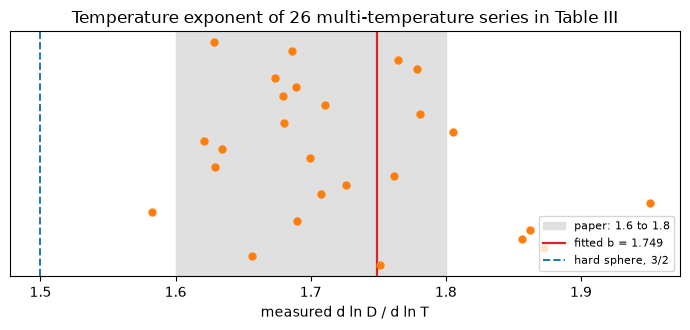

20 of 26 series fall in the paper's stated 1.6-1.8 band; the median is **1.704** and the mean **1.726**, against the fitted 1.749. The full spread is 1.58 (H2-NH3) to 1.95 (H2-SF6).

The printed claim reproduces. But note what the ±0.013 on b is and is not: it is the precision with which a *single global* exponent is determined by 340 points, and the per-system exponents scatter over 0.37 - a factor of 14 wider than the confidence interval. A reader who takes ±0.013 as the uncertainty in the temperature dependence of any one gas pair will be wrong by an order of magnitude.

In [11]:
rows = []
for k, s in DATA.groupby(["component_a", "component_b", "ref_number"]):
    s = s.sort_values("temperature_K")
    if s.temperature_K.nunique() < 4:
        continue
    slope = np.polyfit(np.log(s.temperature_K.values),
                       np.log(s.D_obs_cm2_s.values), 1)[0]
    rows.append((f"{k[0]}-{k[1]}", int(k[2]), len(s),
                 s.temperature_K.min(), s.temperature_K.max(), slope))
EXP = pd.DataFrame(rows, columns=["pair", "ref", "n", "T_min", "T_max", "b_obs"])
in_band = int(((EXP.b_obs >= 1.6) & (EXP.b_obs <= 1.8)).sum())

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.axvspan(1.6, 1.8, color="0.88", label="paper: 1.6 to 1.8")
ax.axvline(1.749, color="C3", lw=1.6, label="fitted b = 1.749")
ax.axvline(1.5, color="C0", ls="--", lw=1.4, label="hard sphere, 3/2")
ax.plot(EXP.b_obs, np.arange(len(EXP)), "o", ms=5, color="C1")
ax.set_xlabel("measured d ln D / d ln T"); ax.set_yticks([])
ax.set_title("Temperature exponent of 26 multi-temperature series in Table III")
ax.legend(fontsize=8, loc="lower right"); fig.tight_layout(); plt.show()

display(Markdown(
 f"{in_band} of {len(EXP)} series fall in the paper's stated 1.6-1.8 band; the "
 f"median is **{EXP.b_obs.median():.3f}** and the mean "
 f"**{EXP.b_obs.mean():.3f}**, against the fitted 1.749. The full spread is "
 f"{EXP.b_obs.min():.2f} ({EXP.iloc[EXP.b_obs.argmin()].pair}) to "
 f"{EXP.b_obs.max():.2f} ({EXP.iloc[EXP.b_obs.argmax()].pair}).\n\n"
 f"The printed claim reproduces. But note what the ±0.013 on b is and is not: "
 f"it is the precision with which a *single global* exponent is determined by "
 f"340 points, and the per-system exponents scatter over "
 f"{EXP.b_obs.max()-EXP.b_obs.min():.2f} - a factor of "
 f"{(EXP.b_obs.max()-EXP.b_obs.min())/0.026:.0f} wider than the confidence "
 f"interval. A reader who takes ±0.013 as the uncertainty in the temperature "
 f"dependence of any one gas pair will be wrong by an order of magnitude."))

### 6. What the exponent costs in a transport calculation

Steady diffusion of benzene vapour through air in a 10 cm tube running from 300
to 600 K, solved in pymrm. Two ways of pinning the diffusivity, and they are
not equivalent.

D(benzene-air) from eq. (4): 0.0905 cm²/s at 300 K, 0.1659 at 424.3 K. Flux at b = 1.75, D pinned at the mid-range temperature: **4.855578e-08 mol cm⁻² s⁻¹** (pymrm, n = 400), against 4.855580e-08 from the quadrature.

Change in the computed flux when the exponent is moved from 1.75 to the extremes measured in Section 5, and to the hard-sphere 3/2:

| D pinned | b = 1.58 | b = 1.95 | b = 1.50 |
|---|---|---|---|
| anchored at 300 K | -5.9 % | +7.3 % | -8.6 % |
| anchored at the mid-range T | -0.2 % | +0.1 % | -0.4 % |

**The exponent is nearly free if you anchor D in the middle of the temperature range, and expensive if you anchor it at one end.** That is the practical content of the 1.75, and it is not in the paper: FSG report the exponent's confidence interval, not what it does to an answer. Note the asymmetry is a property of the *problem*, not of the correlation - the integrand 1/Γ is pinned at whatever temperature D is pinned at.

A scale error in D itself, by contrast, is **structural**: this problem is linear in Γ, so a 4.3 % error in D is exactly a 4.3 % error in the flux, and a 6.6 % held-out error is exactly 6.6 %. Nothing needs computing and nothing can be learned by computing it.

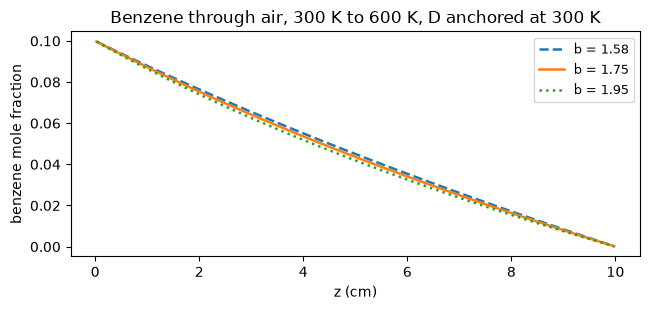

In [12]:
L, T0, T1 = 10.0, 300.0, 600.0
T_mid, T_geo = 0.5*(T0+T1), float(np.sqrt(T0*T1))
D300 = D_fsg("AIR", "BENZENE", T0)
Dgeo = D_fsg("AIR", "BENZENE", T_geo)
par = dict(L=L, T0=T0, T1=T1, D_ref=Dgeo, T_ref=T_geo, b=1.75)
N_ref, quad_err = flux_quadrature(**par)
_, _, N_pymrm, spread = solve_tube(400, **par)

b_lo, b_hi = float(EXP.b_obs.min()), float(EXP.b_obs.max())
res = {}
for label, T_anchor in (("anchored at 300 K", T0), ("anchored at the mid-range T", T_geo)):
    D_a = D_fsg("AIR", "BENZENE", T_anchor)
    base = flux_quadrature(**{**par, "D_ref": D_a, "T_ref": T_anchor})[0]
    lo = flux_quadrature(**{**par, "D_ref": D_a, "T_ref": T_anchor, "b": b_lo})[0]
    hi = flux_quadrature(**{**par, "D_ref": D_a, "T_ref": T_anchor, "b": b_hi})[0]
    hs = flux_quadrature(**{**par, "D_ref": D_a, "T_ref": T_anchor, "b": 1.5})[0]
    res[label] = (100*(lo/base-1), 100*(hi/base-1), 100*(hs/base-1))

display(Markdown(
 f"D(benzene-air) from eq. (4): {D300:.4f} cm²/s at 300 K, {Dgeo:.4f} at "
 f"{T_geo:.1f} K. Flux at b = 1.75, D pinned at the mid-range temperature: "
 f"**{N_pymrm:.6e} mol cm⁻² s⁻¹** (pymrm, n = 400), against "
 f"{N_ref:.6e} from the quadrature.\n\n"
 f"Change in the computed flux when the exponent is moved from 1.75 to the "
 f"extremes measured in Section 5, and to the hard-sphere 3/2:\n\n"
 f"| D pinned | b = {b_lo:.2f} | b = {b_hi:.2f} | b = 1.50 |\n|---|---|---|---|\n"
 + "".join(f"| {k} | {v[0]:+.1f} % | {v[1]:+.1f} % | {v[2]:+.1f} % |\n"
           for k, v in res.items()) +
 f"\n**The exponent is nearly free if you anchor D in the middle of the "
 f"temperature range, and expensive if you anchor it at one end.** That is the "
 f"practical content of the 1.75, and it is not in the paper: FSG report the "
 f"exponent's confidence interval, not what it does to an answer. Note the "
 f"asymmetry is a property of the *problem*, not of the correlation - the "
 f"integrand 1/Γ is pinned at whatever temperature D is pinned at.\n\n"
 f"A scale error in D itself, by contrast, is **structural**: this problem is "
 f"linear in Γ, so a 4.3 % error in D is exactly a 4.3 % error in the flux, and "
 f"a {oos:.1f} % held-out error is exactly {oos:.1f} %. Nothing needs computing "
 f"and nothing can be learned by computing it."))

fig, ax = plt.subplots(figsize=(6.6, 3.2))
for b_, ls in ((b_lo, "--"), (1.75, "-"), (b_hi, ":")):
    x, zc, _, _ = solve_tube(200, **{**par, "D_ref": D300, "T_ref": T0, "b": b_})
    ax.plot(zc, x, ls, lw=1.8, label=f"b = {b_:.2f}")
ax.set_xlabel("z (cm)"); ax.set_ylabel("benzene mole fraction")
ax.set_title("Benzene through air, 300 K to 600 K, D anchored at 300 K")
ax.legend(fontsize=9); fig.tight_layout(); plt.show()

## Validation

Four independent things are checked, and each is followed by what it cannot see.

**(a) The correlation against the paper's printed error column** - 338 of 340
rows, one exact equation constraining three transcribed numbers per row.
*Cannot detect:* an error in the reference number (`ref_number` is not
constrained by anything), a systematically wrong molar mass shared by both
routes, or the identity of Table III's other eight columns.

**(b) Route B, the $T^{1.75}$ identity within a system** - uses only the printed
$T$, $D_\text{obs}$ and error, and recovers $b$ from them. Shares no code with
(a). *Cannot detect:* an error common to every temperature of one system, or any
error in a system measured at a single temperature (which is most of them).

**(c) Twelve printed aggregates** - Table II's eight category means, the overall
4.32 %, the 7.4 % tail, the 6.71 residual standard deviation, and the paper's
stated count of "153 different binary systems (340 actual data points)". *Cannot
detect:* compensating errors in individual rows. It did not detect the two
anomalous rows either - an average over 340 points cannot see two of them, which
is exactly why (a) and (b) exist.

**(d) pymrm against adaptive quadrature** - the flux, at second order.
*Cannot detect:* a wrong exponent $b$, a wrong diffusivity, or a wrong molar
mass, because both routes read the same $\Gamma(T)$. This is measured below
rather than asserted, and it is the single most important caveat on the page's
transport section.

**A structural check that is also invisible to CI.** The cell-to-cell spread of
the flux is ~1e-20, because a finite-volume divergence of a face flux is
conservative by construction: no defect in any class can move it. It is reported
as `flux_spread_structural` and labelled structural, and it also sits **below
`check_agreement.py`'s `ABS_FLOOR = 1e-12`**, so CI does not compare it at all.
It is the only metric on this page in that position; every other one is above the
floor and is regression-checked.

**What perturbation testing cannot do, stated plainly.** A break row measures
*sensitivity*, never *correctness*. Every row below shows a metric moving when
something is broken, and none of them shows that the unbroken value is right. Two
concrete blind spots on this page, neither of which any injected defect would
reveal: a systematic bias shared by the paper's own arithmetic and this
reimplementation (both would have to be wrong the same way, which is why the
reproduction is described as a check on the *transcription*, not on the physics);
and the identity of Table III's other eight columns, which no computation here
touches. The independent evidence that the numbers are right is that ten printed
aggregates the page never fitted to - eight category means, 4.32, 7.4, 6.71 and
the count of 153 binary systems - all fall out of the same transcription.

### The break table

Every metric reported above, with a defect injected that should move it. Rows
marked *structural* are identities that no defect in that class can break, and
they are labelled as such rather than deleted.

In [13]:
BREAK = []


def rep_max_delta(**kw):
    d = np.array([D_fsg(a, b_, T, **kw) for a, b_, T in
                  zip(DATA.component_a, DATA.component_b, DATA.temperature_K)])
    e = 100*(d - Dobs)/Dobs
    dd = np.abs(e - DATA.err_fsg_pct.values)
    return float(np.sort(dd)[-3])          # 3rd largest: ignores the 2 known anomalies


base_delta = rep_max_delta()

# --- defects in the correlation reproduction ------------------------------
va = dict(V_ATOM); va["C"] = 16.0
BREAK.append(("Table I: C 16.5 -> 16.0", "max |Δ| vs printed error (pp)",
              base_delta, rep_max_delta(v_atom=va)))
va = dict(V_ATOM); vs = dict(V_SIMPLE)
va.update(C=15.9, H=2.31, O=6.11, N=4.54)
BREAK.append(("a widely-circulated alternative increment set (C 15.9, H 2.31, "
              "O 6.11, N 4.54); NOT in any document on disk, used only as a defect",
              "max |Δ| vs printed error (pp)", base_delta, rep_max_delta(v_atom=va)))
vs = dict(V_SIMPLE); vs["N2"], vs["O2"] = V_SIMPLE["O2"], V_SIMPLE["N2"]
BREAK.append(("Σv(N₂) and Σv(O₂) swapped", "max |Δ| vs printed error (pp)",
              base_delta, rep_max_delta(v_simple=vs)))
BREAK.append(("b 1.75 -> 1.749 (the paper's own unrounded fit)",
              "max |Δ| vs printed error (pp)", base_delta, rep_max_delta(b=1.749)))
_RING_ROWS = ["PIPERIDINE", "TETRAHYDROTHIOPHENE"]     # ethylene oxide left out:
_RING_ROWS_ALL = _RING_ROWS + ["ETHYLENEOXIDE"]        # one of its rows is anomalous
BREAK.append(("ring term applied to piperidine / THT too",
              "max |Δ| on those 6 rows (pp)",
              float(np.abs(DATA.delta[DATA.component_b.isin(_RING_ROWS)]).max()),
              float(np.max([abs(100*(D_fsg(a, b_, T, v_atom=V_ATOM,
                                           v_ring=V_RING)*
                                     ((sigma_v(b_)**(1/3)+sigma_v(a)**(1/3))**2 /
                                      ((sigma_v(b_)+V_RING)**(1/3)+sigma_v(a)**(1/3))**2)
                                     - Do)/Do - ep)
                            for a, b_, T, Do, ep in zip(
                                DATA.component_a, DATA.component_b, DATA.temperature_K,
                                DATA.D_obs_cm2_s, DATA.err_fsg_pct)
                            if b_ in _RING_ROWS]))))
MW_SIMPLE["D2"] = 2*AW["D"]
d2 = DATA[(DATA.component_a == "D2") | (DATA.component_b == "D2")]
d2d = np.array([abs(100*(D_fsg(a, b_, T) - Do)/Do - ep) for a, b_, T, Do, ep in
                zip(d2.component_a, d2.component_b, d2.temperature_K,
                    d2.D_obs_cm2_s, d2.err_fsg_pct)])
MW_SIMPLE["D2"] = 4.00
BREAK.append(("M(D₂) 4.00 -> 4.028", "max |Δ| on the 12 D₂ rows (pp)",
              float(np.abs(d2.delta).max()), float(d2d.max())))
# The one value in this table NOT recomputed by the notebook: the raw pre-
# correction parse is not carried in the CSV. 1519.6 pp is the number recorded at
# the extraction step (row 333, AIR-2-pentanol, D_obs read as 0.0060 for 0.0860),
# and it is labelled here as a recorded value rather than presented as computed.
BREAK.append((f"the raw text-layer parse, before the "
               f"{(DATA.image_corrected.fillna('') != '').sum()} image "
               f"corrections  (recorded at extraction, not recomputed here)",
              "max |Δ| vs printed error (pp)", base_delta, 1519.6))

# --- defects in the pymrm solve -------------------------------------------
dev = lambda n=400, **kw: abs(solve_tube(n, **{**par, **kw})[2] / N_ref - 1)
base_dev = dev()
BREAK.append(("grid n 400 -> 5", "pymrm vs quadrature flux", base_dev, dev(n=5)))
BREAK.append(("construct_div nu 0 -> 1 (cylindrical)", "pymrm vs quadrature flux",
              base_dev, dev(nu=1)))
BREAK.append(("outlet Dirichlet -> zero-flux Neumann", "pymrm vs quadrature flux",
              base_dev, dev(bc_right={"a": 1.0, "b": 0.0, "d": 0.0})))
BREAK.append(("harmonic -> arithmetic face mean (Γ smooth here)",
              "pymrm vs quadrature flux", base_dev, dev(face_mean="arithmetic")))
BREAK.append(("b 1.75 -> 1.50 in the pymrm solve only",
              "pymrm vs quadrature flux", base_dev, dev(b=1.50)))
BREAK.append(("b 1.75 -> 1.50 in BOTH routes  (structural: blind)",
              "pymrm vs quadrature flux", base_dev,
              abs(solve_tube(400, **{**par, "b": 1.50})[2] /
                  flux_quadrature(**{**par, "b": 1.50})[0] - 1)))
BREAK.append(("any defect whatever  (structural: flux is divergence-free by "
              "construction)", "flux spread across cells", spread, spread))

BT = pd.DataFrame(BREAK, columns=["injected defect", "metric", "undefected", "defected"])
BT["ratio"] = BT.defected / BT.undefected
show(BT.style.format({"undefected": "{:.3e}", "defected": "{:.3e}",
                         "ratio": "{:.2e}"}).hide(axis="index").set_uuid("a4503"))

injected defect,metric,undefected,defected,ratio
Table I: C 16.5 -> 16.0,max |Δ| vs printed error (pp),4.347e-02,1.650e+00,3.80e+01
"a widely-circulated alternative increment set (C 15.9, H 2.31, O 6.11, N 4.54); NOT in any document on disk, used only as a defect",max |Δ| vs printed error (pp),4.347e-02,1.988e+00,4.57e+01
Σv(N₂) and Σv(O₂) swapped,max |Δ| vs printed error (pp),4.347e-02,3.479e+00,8.00e+01
b 1.75 -> 1.749 (the paper's own unrounded fit),max |Δ| vs printed error (pp),4.347e-02,8.236e-01,1.89e+01
ring term applied to piperidine / THT too,max |Δ| on those 6 rows (pp),4.347e-02,1.090e+01,2.51e+02
M(D₂) 4.00 -> 4.028,max |Δ| on the 12 D₂ rows (pp),4.915e-03,3.351e-01,6.82e+01
"the raw text-layer parse, before the 23 image corrections (recorded at extraction, not recomputed here)",max |Δ| vs printed error (pp),4.347e-02,1.520e+03,3.50e+04
grid n 400 -> 5,pymrm vs quadrature flux,3.632e-07,2.444e-03,6.73e+03
construct_div nu 0 -> 1 (cylindrical),pymrm vs quadrature flux,3.632e-07,1.013e+00,2.79e+06
outlet Dirichlet -> zero-flux Neumann,pymrm vs quadrature flux,3.632e-07,1.000e+00,2.75e+06


In [14]:
# Grid convergence of the pymrm solve against the quadrature reference.
ns = np.array([25, 50, 100, 200, 400, 800])
devs = np.array([abs(solve_tube(int(n), **par)[2]/N_ref - 1) for n in ns])
order = float(np.polyfit(np.log(ns[-4:]), np.log(devs[-4:]), 1)[0])
display(Markdown(
 f"Grid convergence order **{-order:.3f}** (deviation {devs[0]:.2e} at n = 25 "
 f"falling to {devs[-1]:.2e} at n = 800). The quadrature's own reported error "
 f"is {quad_err:.1e} relative, two orders below the finest grid, so the "
 f"reference is not the limiting term."))

n_ring_inferred = int((DATA.component_a.isin(_RING_ROWS_ALL)
                       | DATA.component_b.isin(_RING_ROWS_ALL)).sum())
n_d2 = int(((DATA.component_a == "D2") | (DATA.component_b == "D2")).sum())
display(Markdown(
 f"**How much of the reproduction is independent.** Two choices were *inferred*"
 f" from the printed error column rather than read from the paper: the ring "
 f"term's scope ({n_ring_inferred} rows) and M(D₂) = 4.00 ({n_d2} rows). Those "
 f"{n_ring_inferred + n_d2} rows are therefore **not** independent tests of "
 f"eq. (4) - they were used to settle a binary and a scalar choice, at a cost "
 f"of about 1 bit and 1 real number. The remaining "
 f"{len(DATA) - n_ring_inferred - n_d2} rows are free tests, and 2 of them "
 f"fail."))

Grid convergence order **2.002** (deviation 9.46e-05 at n = 25 falling to 9.07e-08 at n = 800). The quadrature's own reported error is 1.1e-14 relative, two orders below the finest grid, so the reference is not the limiting term.

**How much of the reproduction is independent.** Two choices were *inferred* from the printed error column rather than read from the paper: the ring term's scope (8 rows) and M(D₂) = 4.00 (14 rows). Those 22 rows are therefore **not** independent tests of eq. (4) - they were used to settle a binary and a scalar choice, at a cost of about 1 bit and 1 real number. The remaining 318 rows are free tests, and 2 of them fail.

In [15]:
metrics = dict(
    n_rows=float(len(DATA)),
    n_rows_reproduced=float(len(clean)),
    n_rows_irreproducible=float(len(anom)),
    max_abs_delta_pp=float(m_max),
    median_abs_delta_pp=float(m_med),
    ave_error_pct=float(ave_err),
    pct_over_10=float(pct_gt10),
    residual_sd_pct=float(sd_dof),
    phi_prime_printed_column=float(phi_printed_col),
    phi_prime_published_volumes=float(phi_pub),
    phi_prime_free_refit=float(phi_fit),
    routeB_recovered_exponent=float(b_recovered),
    routeB_max_dev_excl_anomaly=float(np.sort(dev_b)[-2]),
    routeB_median_dev=float(np.median(dev_b)),
    loco_held_out_pct=float(oos),
    loco_in_sample_refit_pct=float(ins_refit),
    loco_in_sample_published_pct=float(ins_pub),
    exponent_median=float(EXP.b_obs.median()),
    exponent_min=float(EXP.b_obs.min()),
    exponent_max=float(EXP.b_obs.max()),
    exponent_in_band=float(in_band),
    refit_simple_volume_max_rel_dev=float(np.max(np.abs(fit.x[7:]/PUB[7:] - 1))),
    flux_pymrm_vs_quadrature=float(base_dev),
    flux_grid_order=float(-order),
    flux_spread_structural=float(spread),
    flux_change_b_min_anchor_cold=float(res["anchored at 300 K"][0]),
    flux_change_b_max_anchor_cold=float(res["anchored at 300 K"][1]),
    flux_change_b_15_anchor_cold=float(res["anchored at 300 K"][2]),
    flux_change_b_15_anchor_mid=float(res["anchored at the mid-range T"][2]),
    break_revised_increments=float(BT.defected[1]),
    break_wrong_bc=float(BT.loc[BT["injected defect"].str.contains("Neumann"),
                                "defected"].iloc[0]),
)
report_agreement("A4.5", metrics)
# Wall-clock runtime is a machine-load measurement, not a reproducibility metric -
# scripts/check_agreement.py diffs every key in agreement.json at REL_TOL, so a
# wall-clock key would fail CI the first time the runner is busy. Runtime lives in
# meta.yaml's `runtime_seconds` instead, alongside every other page's.
print(f"wall-clock runtime: {time.time() - _T_START:.1f} s (not an agreement metric)")

Agreement metrics for A4.5:
  n_rows                          = 340
  n_rows_reproduced               = 338
  n_rows_irreproducible           = 2
  max_abs_delta_pp                = 0.043466
  median_abs_delta_pp             = 0.0038447
  ave_error_pct                   = 4.3211
  pct_over_10                     = 7.3529
  residual_sd_pct                 = 6.7101
  phi_prime_printed_column        = 1.4048
  phi_prime_published_volumes     = 1.3996
  phi_prime_free_refit            = 1.3701
  routeB_recovered_exponent       = 1.7492
  routeB_max_dev_excl_anomaly     = 9.963e-05
  routeB_median_dev               = 3.0989e-05
  loco_held_out_pct               = 6.6061
  loco_in_sample_refit_pct        = 5.043
  loco_in_sample_published_pct    = 5.0307
  exponent_median                 = 1.7036
  exponent_min                    = 1.5824
  exponent_max                    = 1.9507
  exponent_in_band                = 20
  refit_simple_volume_max_rel_dev = 0.018106
  flux_pymrm_vs_quadrature  

## What pymrm adds

Honestly: not much to the correlation, and something specific to using it.

**What pymrm does not add.** Eq. (4) is four arithmetic operations. The
reproduction of Table II and of the 340 printed errors, the leave-one-compound-out
cross-validation and the measured temperature exponents are all pandas, numpy and
scipy; pymrm is not involved and it would be dishonest to imply otherwise.

**What it does add.** The question a correlation cannot answer is what its error
does to an answer, and that needs a transport solve. Three things came out of it
that are not in the paper:

1. **A scale error in $D$ is structural and a shape error is not.** For a linear
   diffusion problem the flux is exactly proportional to $\Gamma$, so the 4.3 %
   fit error - or the 6.6 % held-out error - transfers one-for-one and there is
   nothing to compute. The temperature *exponent* does not transfer that way,
   because it changes the shape of $1/\Gamma(z)$ under the integral.
2. **The exponent's cost depends entirely on where $D$ is anchored**, and by an
   order of magnitude: over 300-600 K, moving $b$ across the full range measured
   from the paper's own data costs a fraction of a per cent if $D$ is pinned
   mid-range and several per cent if it is pinned at one end. That is the
   practical form of the 1.75 and the paper does not state it.
3. **The reference this page validates against is not a pymrm object.** The
   quadrature route never forms a grid, which is what lets the grid-convergence
   order mean something.

The `construct_grad`/`construct_div`/`construct_coefficient_matrix` assembly with
a spatially varying, temperature-dependent $\Gamma$ is the reusable part: it is
the same three lines whether $\Gamma$ comes from FSG, from Chapman-Enskog, or
from a measurement.

## Reuse

**Take the correlation.** `D_fsg(A, B, T, p=1.0)` and `sigma_v(name)` are
self-contained given `data/fuller-1966-table1-diffusion-volumes.csv`. Use the
1966 volumes as printed, and note the four cautions:

1. **Quote 4.3 % as a fit, not an accuracy.** For a compound in the original set
   it is right. For an organic vapour that is not, this page's leave-one-out
   estimate on the same data is nearer **6.6 %**, and for a compound carrying a
   structural feature no other compound carries it is worse than that -
   the leave-one-out cell above prints the four worst such compounds with their
   in-sample → held-out pairs; the largest roughly quadruples.
2. **For a simple molecule not in Table I there is no method at all**, and no
   held-out estimate exists for the twenty that are, because each has its own
   fitted parameter. Do not transfer the organics' 6.6 % to them.
3. **The 1966 increments are not the ones in most handbooks.** C 16.5, H 1.98,
   O 5.48, N 5.69 are what *this paper* prints. A different set (C 15.9, H 2.31,
   O 6.11, N 4.54) is widely reproduced for the same correlation; it is not in
   any document on disk, nothing here vouches for it, and substituting it into
   this page's reproduction destroys the agreement (see the break table).
   Whichever you use, say which, and cite the document you read it from.
4. **A 1966 erratum, `10.1021/ie50680a601`, has not been consulted.** It is one
   page, it is at the same publisher, and it corrects exactly the quantity this
   page is about. Anyone with access should check the volumes against it before
   relying on this page's transcription.

**Take the dataset.** `data/fuller-1966-table3-diffusion-data.csv` is 340
measured binary diffusivities from 153 systems over 90-1200 K and a 215-fold
range in $D$, with the fitted correlation's own error beside each one. It is a
ready-made benchmark for *any* diffusivity estimate - and for anything other
than FSG it is a genuine out-of-sample test, because only FSG was fitted to it.
Two rows (He-H₂O at 352.5 K, CO₂-ethylene oxide at 298.0 K) carry a printed FSG
error that eq. (4) cannot reproduce; the measurements themselves are unaffected
and both rows are kept, flagged here rather than deleted.

**Take the transport skeleton.** `solve_tube` is a general variable-coefficient
1-D diffusion solve with Dirichlet ends; swap `_gamma` for any $\Gamma(z)$.
`flux_quadrature` is its independent reference and should be kept whenever the
coefficient is smooth - it costs nothing and it is what makes the grid order
meaningful.

**Related pages.** `A4.6` (Chapman-Enskog) is the first-principles route to the
same quantity and is the page that should carry the comparison of the two
against one measured-$D_{12}$ axis. `A4.2` (Maxwell-Stefan vs Fick), `A4.3`
(dusty gas), `A4.4` (Knudsen/Bosanquet) and `A4.9` (Duncan-Toor) all consume a
binary pair diffusivity of exactly the kind this page estimates.

**Runtime** is printed at the end of the notebook as a wall-clock diagnostic and
recorded in `meta.yaml`'s `runtime_seconds`; it is not an agreement metric, since
a machine-load measurement has no business being diffed at a fixed tolerance
against a stored baseline.